<a href="https://colab.research.google.com/github/EthanSonenshine/NEUR-3002/blob/main/Homework%204.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install spacy scikit-learn matplotlib seaborn ipywidgets
!python -m spacy download en_core_web_md

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"


  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_md-3.8.0/en_core_web_md-3.8.0-py3-none-any.whl (33.5 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

Word Vectors for Inspection:
king: [-0.63784089 -0.5458808   0.06140777 -0.41212527 -0.52546627]...
queen: [-1.1846576  -0.360633    0.02846027 -0.21120598 -0.10272077]...
prince: [-0.62513555 -0.45152395  0.0481394  -0.39294772 -0.6728163 ]...

📊 Cluster Assignments:
          Word  Cluster     PCA_1     PCA_2
0        apple        0  4.340175 -0.587294
1       banana        0  4.571967 -0.692500
2        grape        0  4.692387 -0.489016
3         king        3 -2.884664  2.254923
4        queen        2 -2.119

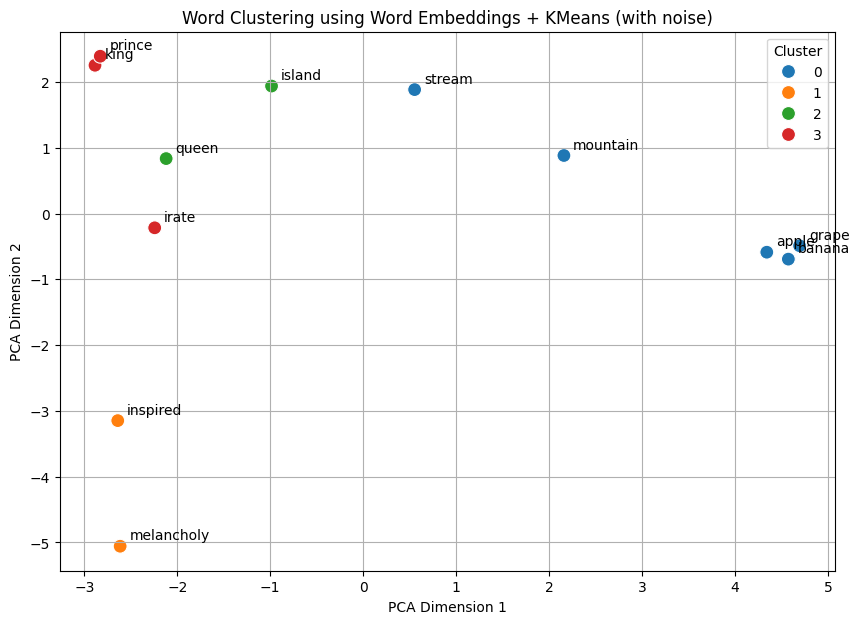

In [13]:
# 📦 Imports
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# Download spaCy model if not already present
!python -m spacy download en_core_web_md

# 🧠 Load spaCy's medium English model (includes word vectors)
nlp = spacy.load("en_core_web_md")

# ✍️ Input: List of words to cluster
words = ["apple", "banana", "grape", "king", "queen", "prince", "mountain", "stream", "island", "melancholy", "inspired", "irate"]

# 🔢 Extract word vectors
word_vectors = [nlp(word).vector for word in words]

# Add Gaussian noise to word vectors to simulate biological variability
# We'll use a mean of 0 and a small standard deviation
noise_mean = 0
noise_std_dev = 0.1 # Adjust this value to control the amount of noise
noisy_word_vectors = []
for vec in word_vectors:
    noise = np.random.normal(noise_mean, noise_std_dev, vec.shape)
    noisy_word_vectors.append(vec + noise)
word_vectors = noisy_word_vectors # Use the noisy vectors for clustering and PCA

# Print vectors for 'king', 'queen', and 'prince' to inspect
print("\nWord Vectors for Inspection:")
for i, word in enumerate(words):
    if word in ["king", "queen", "prince"]:
        print(f"{word}: {word_vectors[i][:5]}...") # Print first 5 dimensions for brevity

# ⚙️ Clustering using KMeans
k = 4  # Number of clusters — adjust as needed
kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
labels = kmeans.fit_predict(word_vectors)

# 🔍 Reduce dimensions for visualization (2D)
pca = PCA(n_components=2)
points_2d = pca.fit_transform(word_vectors)

# 🧾 Show cluster assignments as a table
df = pd.DataFrame({
    "Word": words,
    "Cluster": labels,
    "PCA_1": points_2d[:, 0],
    "PCA_2": points_2d[:, 1]
})
print("\n📊 Cluster Assignments:")
print(df)

# 🎨 Plot the clustered words
plt.figure(figsize=(10, 7))
sns.scatterplot(x=points_2d[:, 0], y=points_2d[:, 1], hue=labels, palette="tab10", s=100)

# Annotate each point with the word
for i, word in enumerate(words):
    plt.text(points_2d[i, 0]+0.1, points_2d[i, 1]+0.1, word)

plt.title("Word Clustering using Word Embeddings + KMeans (with noise)")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()